# Exploratory Data Analysis (EDA)

### Run this code only if you downloaded the dataset's images with **train.py**
> Run **prepare_dataset.py** before running this notebook to download the dataset's pictures on your machine

####1. Import modules

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

####2. Import dataframe and display its columns

In [7]:
DOWNLOADED_IMAGES_PATH = "../data/downloaded_images.csv"

df = pd.read_csv(DOWNLOADED_IMAGES_PATH)

df.columns

Index(['image_id', 'image_url', 'label', 'label_numeric', 'category', 'gender',
       'age_group', 'source', 'fake_method', 'image_quality', 'resolution',
       'confidence_score', 'detection_difficulty', 'dataset_split',
       'date_collected', 'version', 'year', 'image_path'],
      dtype='object')

####3. Display a sample of images
Displays the ones that are labeled as 'FAKE' and is a human, not an emoji.

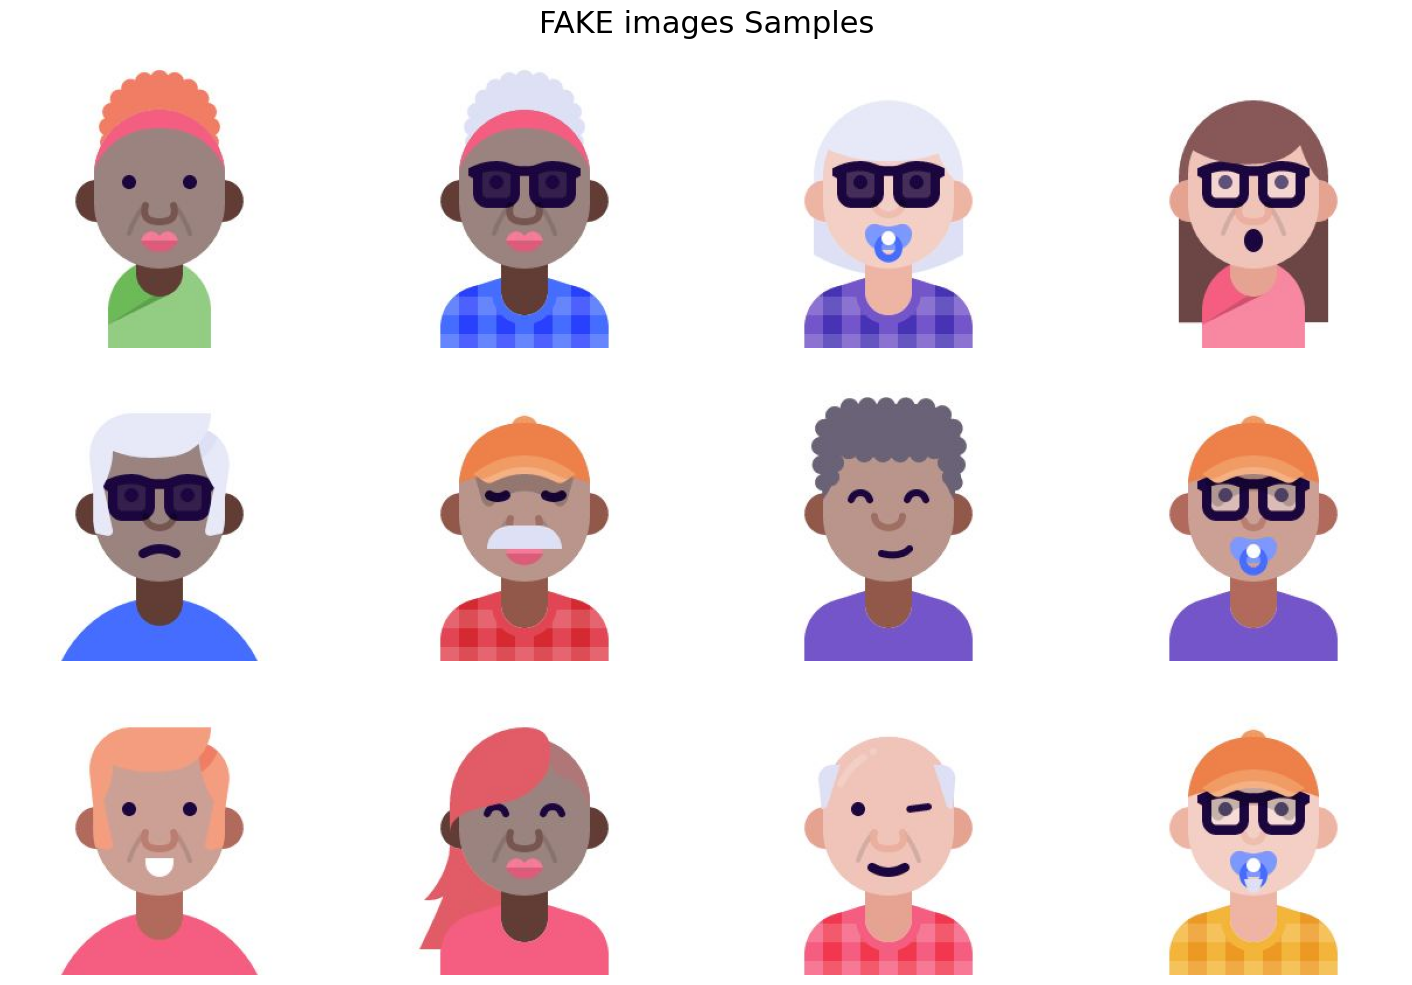

In [8]:

label_name = 'FAKE'

sample_df = df[df['label'] == label_name].sample(12)

fig, axes = plt.subplots(3,4, figsize=(15,10))

axes = axes.flatten()

for ax, (_, row) in zip(axes, sample_df.iterrows()):

    img_path = row['image_path']

    try:
        image = np.asarray(Image.open(img_path))

        ax.imshow(image)
        ax.axis('off')

    except:
        ax.text(0.5,0.5,'Image Error',
                ha='center', va='center')

plt.suptitle(f"{label_name} images Samples", fontsize=22)

plt.tight_layout()
plt.show()

####4. Real vs fake distribution

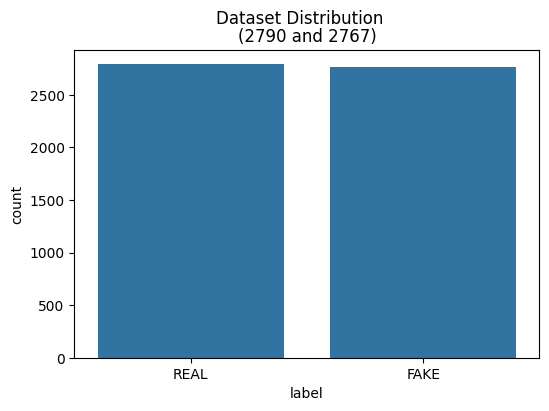

In [9]:
plt.figure(figsize=(6, 4))

sns.countplot(x = 'label', data = df)

plt.suptitle("Dataset Distribution")
plt.title(f"({len(df[df['label'] == 'REAL'])} and {len(df[df['label'] == 'FAKE'])})")
plt.show()

####5. Age group analysis

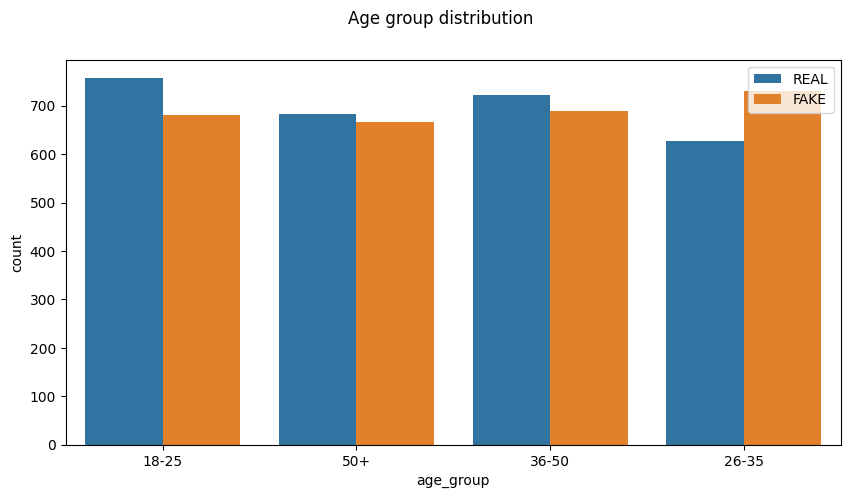

In [10]:
plt.figure(figsize=(10, 5))

sns.countplot(x = 'age_group', data= df, hue= 'label')

plt.suptitle("Age group distribution")
plt.legend()
plt.show()

####6. Confidence score distribution

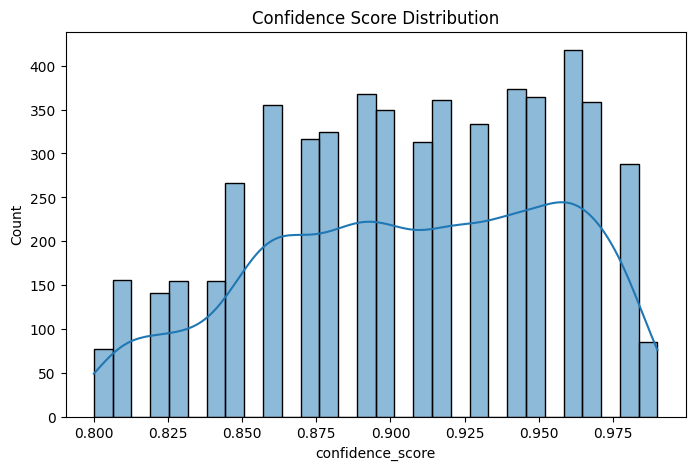

In [11]:
plt.figure(figsize=(8,5))

sns.histplot(df['confidence_score'], bins=30, kde=True)

plt.title("Confidence Score Distribution")
plt.show()

####7. Gender Distribution

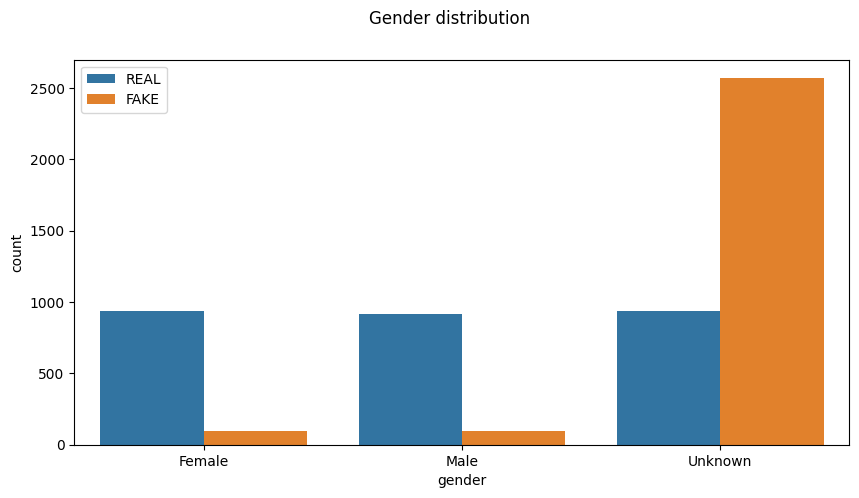

In [12]:
plt.figure(figsize=(10, 5))

sns.countplot(x = 'gender', data= df, hue= 'label')

plt.suptitle("Gender distribution")
plt.legend()
plt.show()

## Conclusion:
From this data analysis, we can see that after filtering, there is an almost egal distribution of values between the fake and real pictures. Also, most of the 'fake' pictures are emojis, and just a little part contains actual humans, most of them appearing to be ai generated.